In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/raw_federal_spending.csv", low_memory=False)

df.head()

,contract_transaction_unique_key,contract_award_unique_key,award_id_piid,modification_number,transaction_number,parent_award_agency_id,parent_award_agency_name,parent_award_id_piid,parent_award_modification_number,federal_action_obligation,...,highly_compensated_officer_2_name,highly_compensated_officer_2_amount,highly_compensated_officer_3_name,highly_compensated_officer_3_amount,highly_compensated_officer_4_name,highly_compensated_officer_4_amount,highly_compensated_officer_5_name,highly_compensated_officer_5_amount,usaspending_permalink,last_modified_date
0,9700_9700_SPE2DX21FEPUZ_0_SPE2DX19D5041_0,CONT_AWD_SPE2DX21FEPUZ_9700_SPE2DX19D5041_9700,SPE2DX21FEPUZ,0,0.0,9700,DEPT OF DEFENSE,SPE2DX19D5041,0,386.69,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_SPE...,2021-05-20 02:19:47
1,9700_9700_SPE3SU21F693Z_0_SPE30018DS335_0,CONT_AWD_SPE3SU21F693Z_9700_SPE30018DS335_9700,SPE3SU21F693Z,0,0.0,9700,DEPT OF DEFENSE,SPE30018DS335,0,620.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_SPE...,2021-03-09 19:45:23
2,4732_4732_47QMCA21F03NX_0_47QMCA20D004B_0,CONT_AWD_47QMCA21F03NX_4732_47QMCA20D004B_4732,47QMCA21F03NX,0,0.0,4732,FEDERAL ACQUISITION SERVICE,47QMCA20D004B,0,177625.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_47Q...,2021-01-29 21:19:04
3,4732_4732_47QSCC21F4BLQ_0_47QSCC21A0001_0,CONT_AWD_47QSCC21F4BLQ_4732_47QSCC21A0001_4732,47QSCC21F4BLQ,0,0.0,4732,FEDERAL ACQUISITION SERVICE,47QSCC21A0001,PS0001,18319.20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_47Q...,2021-07-15 05:09:33
4,9700_9700_SPE4A221F6549_0_SPE4AX19D9438_0,CONT_AWD_SPE4A221F6549_9700_SPE4AX19D9438_9700,SPE4A221F6549,0,0.0,9700,DEPT OF DEFENSE,SPE4AX19D9438,0,4598.30,...,JACK ROVAN,150529.0,KELLY WALSH,130000.0,TERRY HOGAN,123822.0,ALAN BORING,120182.0,https://www.usaspending.gov/award/CONT_AWD_SPE...,2022-02-13 06:34:20


In [5]:
# Clean and prepare DMV federal spending dataset

# Select possible columns from the raw dataset
possible_columns = {
    "recipient_name": "Recipient",
    "awarding_agency_name": "Agency",
    "funding_agency_name": "Funding_Agency",
    "place_of_performance_state_code": "State",
    "place_of_performance_state_name": "State_Name",
    "place_of_performance_city_name": "City",
    "action_date": "Action_Date",
    "period_of_performance_start_date": "Start_Date",
    "total_obligation": "Obligation_Amount",
    "current_total_value_of_award": "Award_Value",
    "naics_description": "Industry",
    "award_description": "Award_Description"
}

existing_columns = [col for col in possible_columns if col in df.columns]

df_clean = df[existing_columns].copy()
df_clean = df_clean.rename(columns={col: possible_columns[col] for col in existing_columns})

# Identify the state column safely
if "State" in df_clean.columns:
    state_column = "State"
elif "State_Name" in df_clean.columns:
    state_column = "State_Name"
else:
    state_column = None

# Filter for DMV states only
if state_column == "State":
    dmv_values = ["VA", "MD", "DC"]
    df_clean = df_clean[df_clean[state_column].isin(dmv_values)]
elif state_column == "State_Name":
    dmv_values = ["Virginia", "Maryland", "District of Columbia"]
    df_clean = df_clean[df_clean[state_column].isin(dmv_values)]

# Standardize state column name
if state_column is not None:
    df_clean = df_clean.rename(columns={state_column: "State"})

# Convert date columns if they exist
if "Action_Date" in df_clean.columns:
    df_clean["Action_Date"] = pd.to_datetime(df_clean["Action_Date"], errors="coerce")

if "Start_Date" in df_clean.columns:
    df_clean["Start_Date"] = pd.to_datetime(df_clean["Start_Date"], errors="coerce")

# Convert obligation amount to numeric if it exists
if "Obligation_Amount" in df_clean.columns:
    df_clean["Obligation_Amount"] = pd.to_numeric(df_clean["Obligation_Amount"], errors="coerce")
    df_clean = df_clean[df_clean["Obligation_Amount"] > 0]

# Remove rows with missing key values
key_columns = [col for col in ["Recipient", "Agency", "State", "Obligation_Amount"] if col in df_clean.columns]
df_clean = df_clean.dropna(subset=key_columns)

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Save cleaned files
df_clean.to_csv("../data/processed/cleaned_data.csv", index=False)
df_clean.to_excel("../data/processed/cleaned_data.xlsx", index=False)

# Create GitHub preview sample
sample_df = df_clean.head(100)

sample_df.to_csv("../data/processed/cleaned_data_sample.csv", index=False)
sample_df.to_excel("../data/processed/cleaned_data_sample.xlsx", index=False)

print("Cleaned DMV dataset created successfully.")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
df_clean.head()

Cleaned DMV dataset created successfully.
Rows: 361038
Columns: 8


,Recipient,Agency,Funding_Agency,Action_Date,Start_Date,Award_Value,Industry,Award_Description
0,AMERISOURCEBERGEN DRUG CORPORATION,DEPARTMENT OF DEFENSE (DOD),DEPARTMENT OF DEFENSE (DOD),2021-02-03,2021-02-03,386.69,DRUGS AND DRUGGISTS' SUNDRIES MERCHANT WHOLESA...,4552408814!PRIME VENDOR PHARM BRANCH-PHILADELPHIA
1,"OAKES FARMS FOOD & DISTRIBUTION SERVICES, LLC",DEPARTMENT OF DEFENSE (DOD),DEPARTMENT OF DEFENSE (DOD),2021-01-27,2021-01-27,620.34,PERISHABLE PREPARED FOOD MANUFACTURING,"4552333138!ORANGE WEDGES, CHL,"
2,FORD MOTOR COMPANY,GENERAL SERVICES ADMINISTRATION (GSA),GENERAL SERVICES ADMINISTRATION (GSA),2021-01-28,2021-01-28,177625.00,AUTOMOBILE MANUFACTURING,"4X2 PICKUP, FULL SIZE, CREW CAB, MIN 6000 LBS ..."
3,"W.W. GRAINGER, INC.",GENERAL SERVICES ADMINISTRATION (GSA),GENERAL SERVICES ADMINISTRATION (GSA),2021-07-14,2021-07-14,18319.20,HOME CENTERS,REFRIGERATOR BLACK 8 CU FT.
4,"MARTIN-BAKER AMERICA, INC.",DEPARTMENT OF DEFENSE (DOD),DEPARTMENT OF DEFENSE (DOD),2021-08-20,2021-08-20,4598.30,OTHER AIRCRAFT PARTS AND AUXILIARY EQUIPMENT M...,"8508468655!GARTER,LEG SET"


In [6]:
# Find location-related columns
location_columns = [col for col in df.columns if "state" in col.lower() or "performance" in col.lower() or "place" in col.lower()]
location_columns

['period_of_performance_start_date',
 'period_of_performance_current_end_date',
 'period_of_performance_potential_end_date',
 'recipient_state_code',
 'recipient_state_name',
 'primary_place_of_performance_country_code',
 'primary_place_of_performance_country_name',
 'primary_place_of_performance_city_name',
 'primary_place_of_performance_county_name',
 'primary_place_of_performance_state_code',
 'primary_place_of_performance_state_name',
 'primary_place_of_performance_zip_4',
 'primary_place_of_performance_congressional_district',
 'place_of_manufacture_code',
 'place_of_manufacture',
 'performance_based_service_acquisition_code',
 'performance_based_service_acquisition',
 'us_state_government',
 'interstate_entity',
 'state_controlled_institution_of_higher_learning']

In [7]:
# Create final DMV-focused dataset

columns_needed = {
    "recipient_name": "Recipient",
    "awarding_agency_name": "Agency",
    "funding_agency_name": "Funding_Agency",
    "primary_place_of_performance_state_code": "State",
    "primary_place_of_performance_city_name": "City",
    "action_date": "Action_Date",
    "period_of_performance_start_date": "Start_Date",
    "current_total_value_of_award": "Award_Value",
    "naics_description": "Industry",
    "award_description": "Award_Description"
}

existing_columns = [col for col in columns_needed if col in df.columns]

df_clean = df[existing_columns].copy()

df_clean = df_clean.rename(
    columns={col: columns_needed[col] for col in existing_columns}
)

# Filter only DMV states
dmv_states = ["VA", "MD", "DC"]

df_clean = df_clean[
    df_clean["State"].isin(dmv_states)
]

# Convert dates
df_clean["Action_Date"] = pd.to_datetime(
    df_clean["Action_Date"],
    errors="coerce"
)

df_clean["Start_Date"] = pd.to_datetime(
    df_clean["Start_Date"],
    errors="coerce"
)

# Convert award values to numeric
df_clean["Award_Value"] = pd.to_numeric(
    df_clean["Award_Value"],
    errors="coerce"
)

# Remove invalid values
df_clean = df_clean.dropna(
    subset=["Recipient", "Agency", "State", "Award_Value"]
)

df_clean = df_clean[
    df_clean["Award_Value"] > 0
]

# Remove duplicates
df_clean = df_clean.drop_duplicates()

# Save cleaned files
df_clean.to_csv(
    "../data/processed/cleaned_data.csv",
    index=False
)

df_clean.to_excel(
    "../data/processed/cleaned_data.xlsx",
    index=False
)

# Create GitHub preview sample
sample_df = df_clean.head(100)

sample_df.to_csv(
    "../data/processed/cleaned_data_sample.csv",
    index=False
)

sample_df.to_excel(
    "../data/processed/cleaned_data_sample.xlsx",
    index=False
)

print("Final DMV dataset created successfully.")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

df_clean.head()

Final DMV dataset created successfully.
Rows: 43931
Columns: 10


,Recipient,Agency,Funding_Agency,State,City,Action_Date,Start_Date,Award_Value,Industry,Award_Description
7,"EMMES CORPORATION, THE",DEPARTMENT OF HEALTH AND HUMAN SERVICES (HHS),DEPARTMENT OF HEALTH AND HUMAN SERVICES (HHS),MD,ROCKVILLE,2021-05-27,2017-07-28,33003900.87,RESEARCH AND DEVELOPMENT IN BIOTECHNOLOGY,DATA COORDINATING CENTER FOR THE BEST PHARMACE...
24,"NORFOLK BANANA DISTRIBUTORS, INC.",DEPARTMENT OF DEFENSE (DOD),DEPARTMENT OF DEFENSE (DOD),VA,NORFOLK,2020-11-12,2020-11-12,289.15,PERISHABLE PREPARED FOOD MANUFACTURING,"4551700637!LETTUCE, FRESH,"
41,"ROHDE & SCHWARZ USA, INC.",DEPARTMENT OF DEFENSE (DOD),DEPARTMENT OF DEFENSE (DOD),MD,COLUMBIA,2021-07-01,2021-05-12,14905.00,OTHER ELECTRONIC AND PRECISION EQUIPMENT REPAI...,OEM REPAIR OF NRP-Z52 (S/N: 162002)
49,W R SYSTEMS LTD.,DEPARTMENT OF DEFENSE (DOD),DEPARTMENT OF DEFENSE (DOD),VA,FAIRFAX,2021-06-17,2021-06-17,377404.17,ENGINEERING SERVICES,NGA CHARTING APPLICATION DEVELOPMENT AND MAINT...
51,"GENERAL DYNAMICS INFORMATION TECHNOLOGY, INC.",DEPARTMENT OF DEFENSE (DOD),DEPARTMENT OF DEFENSE (DOD),VA,FALLS CHURCH,2021-03-22,2021-03-22,3632.02,OTHER COMMUNICATIONS EQUIPMENT MANUFACTURING,CIRCUIT CARD ASSEMB


In [8]:
import matplotlib.pyplot as plt

# Summary tables
spending_by_state = df_clean.groupby("State")["Award_Value"].sum().sort_values(ascending=False)
top_agencies = df_clean.groupby("Agency")["Award_Value"].sum().sort_values(ascending=False).head(10)
top_recipients = df_clean.groupby("Recipient")["Award_Value"].sum().sort_values(ascending=False).head(10)
top_industries = df_clean.groupby("Industry")["Award_Value"].sum().sort_values(ascending=False).head(10)

# Save output CSV files
spending_by_state.to_csv("../outputs/spending_by_state.csv")
top_agencies.to_csv("../outputs/top_agencies.csv")
top_recipients.to_csv("../outputs/top_recipients.csv")
top_industries.to_csv("../outputs/top_industries.csv")

print("Analysis output files created successfully.")

Analysis output files created successfully.


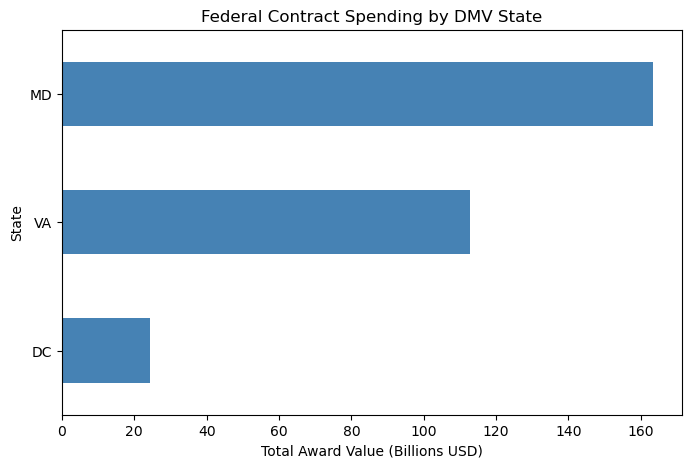

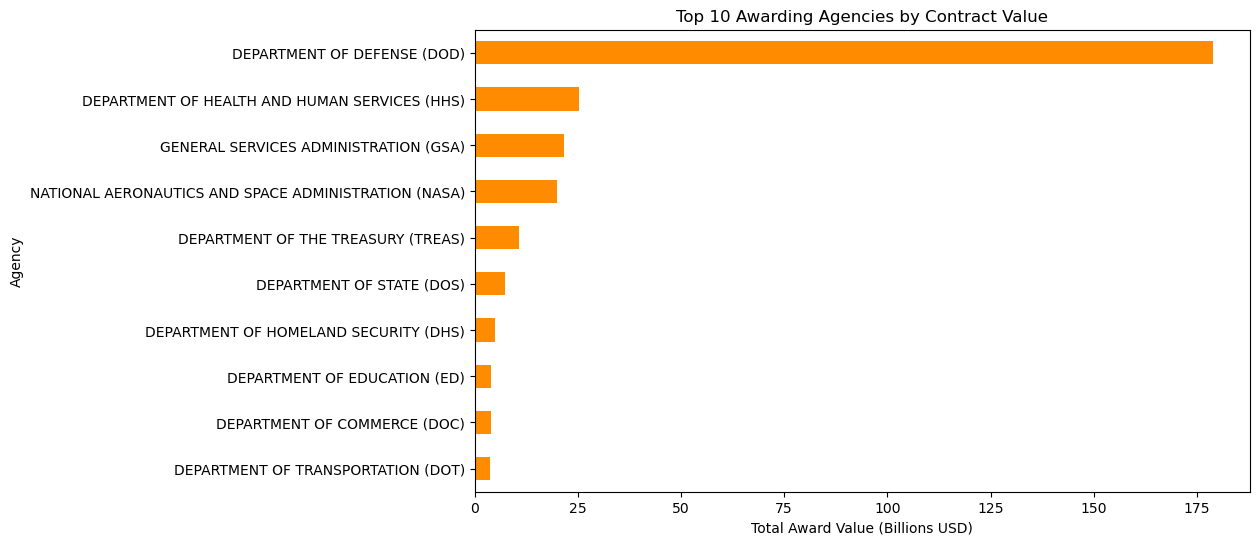

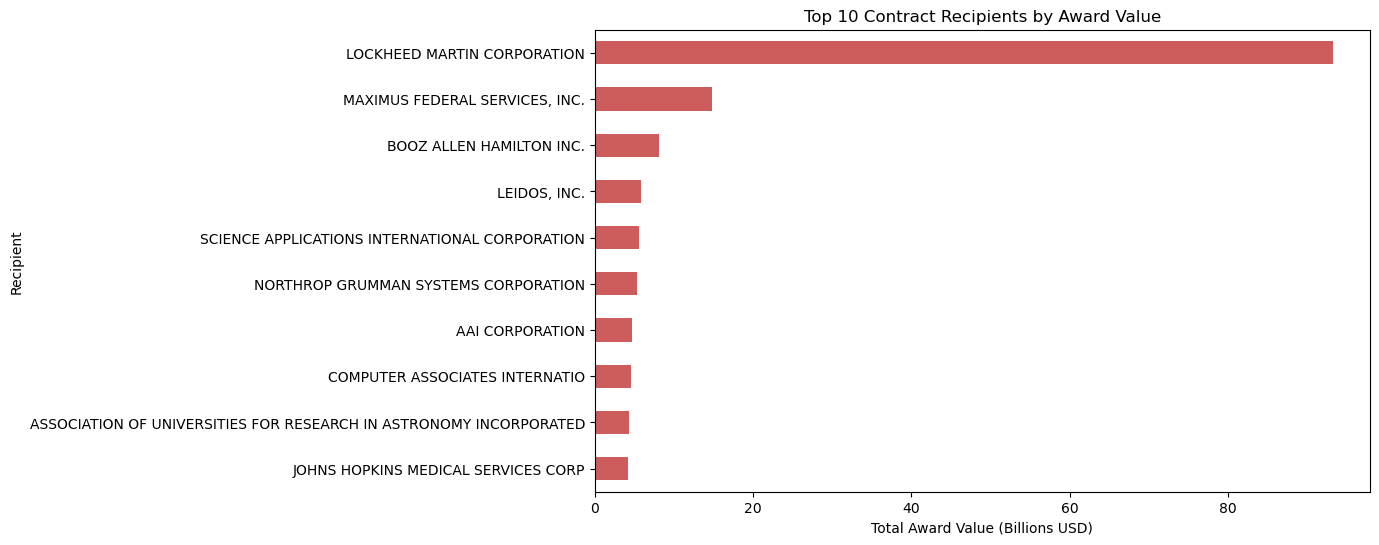

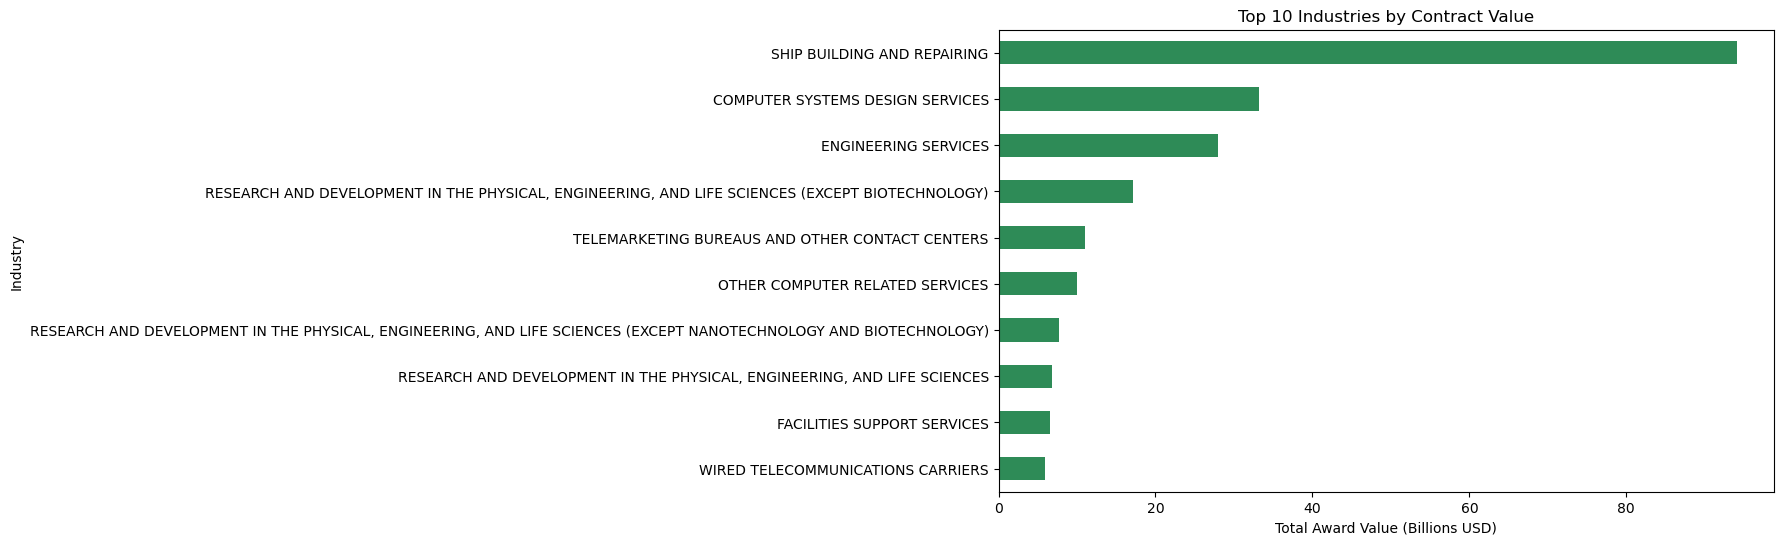

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Visual 1: Total Spending by DMV State
plt.figure(figsize=(8, 5))
(spending_by_state / 1_000_000_000).sort_values().plot(kind="barh", color="steelblue")
plt.title("Federal Contract Spending by DMV State")
plt.xlabel("Total Award Value (Billions USD)")
plt.ylabel("State")
plt.savefig("../images/spending_by_state.png", bbox_inches="tight")
plt.show()

# Visual 2: Top 10 Awarding Agencies
plt.figure(figsize=(10, 6))
(top_agencies / 1_000_000_000).sort_values().plot(kind="barh", color="darkorange")
plt.title("Top 10 Awarding Agencies by Contract Value")
plt.xlabel("Total Award Value (Billions USD)")
plt.ylabel("Agency")
plt.savefig("../images/top_agencies.png", bbox_inches="tight")
plt.show()

# Visual 3: Top 10 Contract Recipients
plt.figure(figsize=(10, 6))
(top_recipients / 1_000_000_000).sort_values().plot(kind="barh", color="indianred")
plt.title("Top 10 Contract Recipients by Award Value")
plt.xlabel("Total Award Value (Billions USD)")
plt.ylabel("Recipient")
plt.savefig("../images/top_recipients.png", bbox_inches="tight")
plt.show()

# Visual 4: Top 10 Industries
plt.figure(figsize=(10, 6))
(top_industries / 1_000_000_000).sort_values().plot(kind="barh", color="seagreen")
plt.title("Top 10 Industries by Contract Value")
plt.xlabel("Total Award Value (Billions USD)")
plt.ylabel("Industry")
plt.savefig("../images/top_industries.png", bbox_inches="tight")
plt.show()

In [11]:
df_clean.head(15)

,Recipient,Agency,Funding_Agency,State,City,Action_Date,Start_Date,Award_Value,Industry,Award_Description
7,"EMMES CORPORATION, THE",DEPARTMENT OF HEALTH AND HUMAN SERVICES (HHS),DEPARTMENT OF HEALTH AND HUMAN SERVICES (HHS),MD,ROCKVILLE,2021-05-27,2017-07-28,33003900.87,RESEARCH AND DEVELOPMENT IN BIOTECHNOLOGY,DATA COORDINATING CENTER FOR THE BEST PHARMACE...
24,"NORFOLK BANANA DISTRIBUTORS, INC.",DEPARTMENT OF DEFENSE (DOD),DEPARTMENT OF DEFENSE (DOD),VA,NORFOLK,2020-11-12,2020-11-12,289.15,PERISHABLE PREPARED FOOD MANUFACTURING,"4551700637!LETTUCE, FRESH,"
41,"ROHDE & SCHWARZ USA, INC.",DEPARTMENT OF DEFENSE (DOD),DEPARTMENT OF DEFENSE (DOD),MD,COLUMBIA,2021-07-01,2021-05-12,14905.00,OTHER ELECTRONIC AND PRECISION EQUIPMENT REPAI...,OEM REPAIR OF NRP-Z52 (S/N: 162002)
49,W R SYSTEMS LTD.,DEPARTMENT OF DEFENSE (DOD),DEPARTMENT OF DEFENSE (DOD),VA,FAIRFAX,2021-06-17,2021-06-17,377404.17,ENGINEERING SERVICES,NGA CHARTING APPLICATION DEVELOPMENT AND MAINT...
51,"GENERAL DYNAMICS INFORMATION TECHNOLOGY, INC.",DEPARTMENT OF DEFENSE (DOD),DEPARTMENT OF DEFENSE (DOD),VA,FALLS CHURCH,2021-03-22,2021-03-22,3632.02,OTHER COMMUNICATIONS EQUIPMENT MANUFACTURING,CIRCUIT CARD ASSEMB
52,"PRODUCE SOURCE PARTNERS, INC.",DEPARTMENT OF DEFENSE (DOD),DEPARTMENT OF DEFENSE (DOD),VA,ASHLAND,2020-10-14,2020-10-14,197.95,PERISHABLE PREPARED FOOD MANUFACTURING,"4551402899!PEARS, FRESH,"
66,"OFFICE DEPOT, INC.",GENERAL SERVICES ADMINISTRATION (GSA),GENERAL SERVICES ADMINISTRATION (GSA),MD,COLUMBIA,2020-12-15,2020-12-15,42.83,OFFICE SUPPLIES (EXCEPT PAPER) MANUFACTURING,"SPRAY,CLEAN-UP,32OZ"
79,"GOVERNMENT SCIENTIFIC SOURCE, INC.",DEPARTMENT OF DEFENSE (DOD),DEPARTMENT OF DEFENSE (DOD),VA,RESTON,2021-08-26,2021-08-26,1082417.58,ALL OTHER MISCELLANEOUS MANUFACTURING,4554568557!NOVASEQ 6000
82,NATIONAL INDUSTRIES FOR THE BLIND,GENERAL SERVICES ADMINISTRATION (GSA),GENERAL SERVICES ADMINISTRATION (GSA),VA,ALEXANDRIA,2021-03-15,2021-03-15,33.06,OTHER COMMERCIAL AND SERVICE INDUSTRY MACHINER...,"GLOVES,DISPOSABLE,NITRILE:AMBIDEXTROUS,POWDER-..."
92,"W.E. BOWERS, INC.",NATIONAL GALLERY OF ART (NGA),NATIONAL GALLERY OF ART (NGA),DC,WASHINGTON,2021-03-30,2021-04-01,63629.00,"PLUMBING, HEATING, AND AIR-CONDITIONING CONTRA...",MECHANICAL IDIQ
